In [1]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
import torch
from scipy.special import softmax
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
#Load model
MODEL_NAME = "hannybal/disaster-twitter-xlm-roberta-al"
TOKENIZER_NAME = "cardiffnlp/twitter-xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
config = AutoConfig.from_pretrained(MODEL_NAME)

In [3]:
def preprocess(text: str) -> str:
    new_text = []
    for t in text.split(" "):
        t = "@user" if t.startswith("@") else t
        t = "http" if t.startswith("http") else t
        new_text.append(t)
    return " ".join(new_text)

In [4]:
#Load dataset
df = pd.read_csv("../datasets/train.csv").dropna(subset=["text"]).reset_index(drop=True)
df["clean_text"] = df["text"].apply(preprocess)

In [5]:
preds = []
confs = []
proba = []

#Perform batch inferences
for text in tqdm(df["clean_text"], desc="Running batch inference"):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        output = model(**inputs)
    scores = softmax(output.logits[0].cpu().numpy())
    pred = int(np.argmax(scores))
    conf = float(scores[pred])
    preds.append(pred)
    confs.append(conf)
    proba.append(scores.tolist())

df["predicted"] = preds
df["confidence"] = confs
df["probs"] = proba

Running batch inference: 100%|███| 7613/7613 [05:04<00:00, 25.01it/s]


In [6]:
y_true = df["target"].values
y_pred = df["predicted"].values
y_probs = np.array(df["probs"].tolist())

#Print reports
print("Classification Report")
print(classification_report(y_true, y_pred, target_names=["Not Disaster", "Disaster"]))

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_true, y_probs):.4f}")

Classification Report
              precision    recall  f1-score   support

Not Disaster       0.69      0.95      0.80      4342
    Disaster       0.87      0.44      0.58      3271

    accuracy                           0.73      7613
   macro avg       0.78      0.69      0.69      7613
weighted avg       0.77      0.73      0.71      7613

Accuracy: 0.7303
Precision: 0.8718
Recall: 0.4366
F1 Score: 0.5818
Log Loss: 2.5022


/Volumes/T7/dev/nlp-comp-env/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


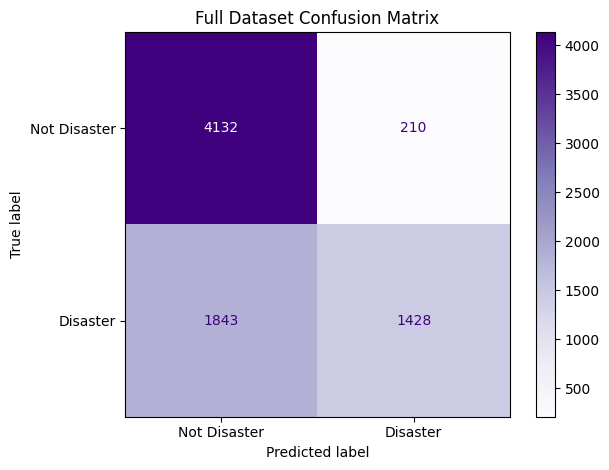

In [7]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Disaster", "Disaster"])
#Plot confusion matrix
disp.plot(cmap="Purples")
plt.title("Full Dataset Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

In [8]:
#Show FPs + FNs
fp = df[(df["target"] == 0) & (df["predicted"] == 1)]
fn = df[(df["target"] == 1) & (df["predicted"] == 0)]

print(f"False Positives: {len(fp)}")
display(fp[["text", "confidence"]].head())

print(f"\nFalse Negatives: {len(fn)}")
display(fn[["text", "confidence"]].head())

False Positives: 210


,text,confidence
205,What's the police or ambulance number in Lesot...,0.945289
246,U.S National Park Services Tonto National Fore...,0.999584
250,U.S National Park Services Tonto National Fore...,0.999584
259,U.S National Park Services Tonto National Fore...,0.999584
266,U.S National Park Services Tonto National Fore...,0.999584



False Negatives: 1843


,text,confidence
0,Our Deeds are the Reason of this #earthquake M...,0.999944
4,Just got sent this photo from Ruby #Alaska as ...,0.999900
7,I'm on top of the hill and I can see a fire in...,0.999907
10,Three people died from the heat wave so far,0.995421
14,Damage to school bus on 80 in multi car crash ...,0.896986


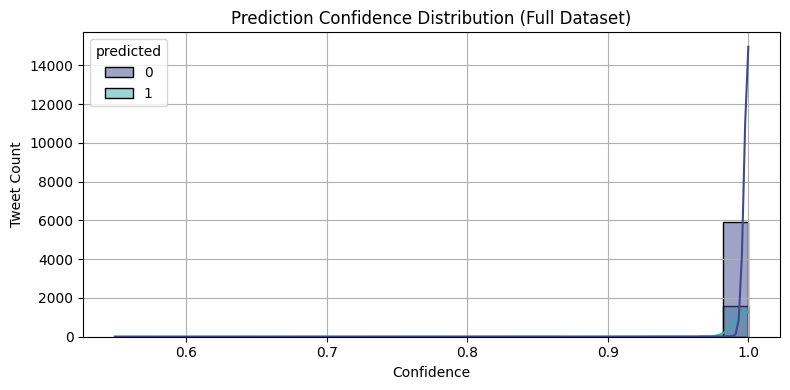

In [9]:
#Plots confidence distribution
plt.figure(figsize=(8, 4))
sns.histplot(df, x="confidence", hue="predicted", bins=25, kde=True, palette="mako")
plt.title("Prediction Confidence Distribution (Full Dataset)")
plt.xlabel("Confidence")
plt.ylabel("Tweet Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
df.to_csv("../notebooks/logs/eval_predictions_full.csv", index=False)
print("Saved full dataset evaluation to logs/eval_predictions_full.csv")

Saved full dataset evaluation to logs/eval_predictions_full.csv


In [15]:
y_true = df["target"].values
y_prob_disaster = df["probs"].apply(lambda x: x[1]).values

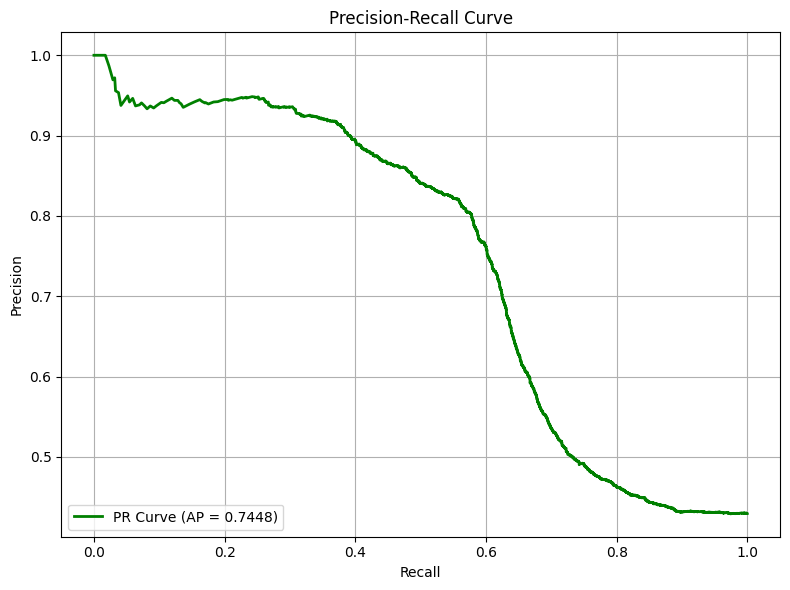

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob_disaster)
ap_score = average_precision_score(y_true, y_prob_disaster)

#Plot precission-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="green", lw=2, label=f"PR Curve (AP = {ap_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

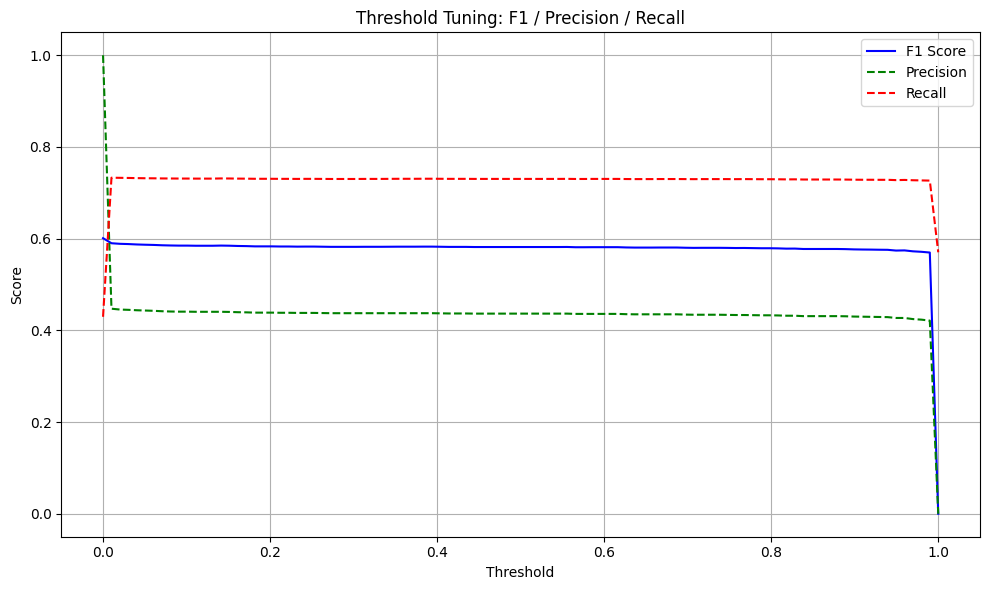

In [17]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 100)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    preds = (y_prob_disaster >= t).astype(int)
    f1s.append(f1_score(y_true, preds))
    precisions.append(np.mean(preds[y_true == 1] == 1) if np.any(preds) else 0)
    recalls.append(np.mean(preds == y_true))

#Plot threshold tuning
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1s, label="F1 Score", color="blue")
plt.plot(thresholds, precisions, label="Precision", color="green", linestyle="--")
plt.plot(thresholds, recalls, label="Recall", color="red", linestyle="--")
plt.title("Threshold Tuning: F1 / Precision / Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


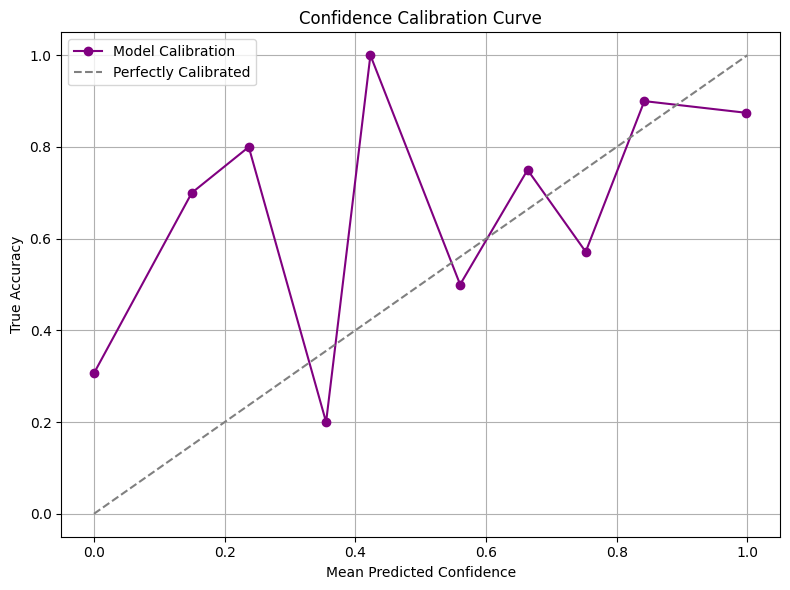

In [18]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_true, y_prob_disaster, n_bins=10)

#Plot confidence calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model Calibration", color="purple")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly Calibrated")
plt.title("Confidence Calibration Curve")
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("True Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
df.to_csv("../notebooks/logs/eval_predictions_full_ext.csv", index=False)
print("Saved full dataset evaluation to logs/eval_predictions_full_ext.csv")

Saved full dataset evaluation to logs/eval_predictions_full_ext.csv
